In [1]:
from PatientDataset import PatientDataset
from collate import collate_fn
import numpy as np
from torch.utils.data import Subset
import torch
from torch import nn, optim
from MultimodalTransformer import MultimodalTransformer
from LateFusion import LateFusionModule
from EarlyFusion import EarlyFusionModule
import yaml
from utils import get_class_weights, test_model, train_model_earlystop, print_mod_distribution
from plots import plot_attn_matrix
from functools import partial
from datetime import datetime
import os 
import json
import warnings
import random
import pandas as pd
import torch
import random
from torch.utils.data import Dataset
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

In [2]:
def to_float(x):
    if isinstance(x, np.ndarray):
        return float(x)
    return float(x)

def to_tensor(x):
    if isinstance(x, torch.Tensor):
        return x
    return torch.tensor(x)
   
def unwrap(test):
    if isinstance(test, tuple):
        return test[0]
    return test
def set_seed(seed=42):
    random.seed(seed)

    np.random.seed(seed)

    torch.manual_seed(seed)

    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # deterministic ops
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

def get_cls_attn(all_patient_seq, pid):
    patient_seq = all_patient_seq[pid]
    cls_rollout = patient_seq['cls_rollout']
    mask = (cls_rollout != 0)  # (N, T)

    return cls_rollout, mask

In [3]:
# Load config file
with open('config.yaml', "r") as f:
    cfg = yaml.safe_load(f)

params = {
    'd_model': 256,
    'num_heads': 4,
    'num_layers': 2,
    'dropout': 0.2723195214333366,
    'num_epochs': 100,
    'batch_size': 32,
    'lr': 0.00013,
    # for early stopping
    'min_train_epochs': 5,
    'patience':20     
}  

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("On device:", device)

modality_names = [
            m["name"].lower()
            for m in cfg["modalities"]
            if not m.get("mask", False) # dont add modality if mask set to True in config file
        ]
# -- Create Dataset
whole_dataset = PatientDataset(cfg, inference_cols=None)

On device: cuda:0


In [6]:
fusion_strategy = cfg["fusion_strategy"]
early, late = False, False
if fusion_strategy == 'early':
    early=True
elif fusion_strategy == 'late':
    late=True

fusion_head = 'mean'

exp_dir = 'experiments'
mask_imp = '0708_0047-unimodal-demographics-diagnosis-VS12'

compute_all_metrics = False if late or early else True 

configuration = f'{mask_imp}'
mask_missing=True # if mask_imp=='mask' else False #False for IMP , True for Mask
folds_path = cfg["folds_path"]
patient_ids = None


# Test results for all patients

In [7]:
balaccs, rocaucs = [], []
all_patient_results={}
for fold, (train_idx, val_idx) in enumerate(np.load(folds_path, allow_pickle=True)):
    print("-- Fold ", fold)
    set_seed(42 * 1000 + fold)
    if patient_ids is None:
        patient_indices=val_idx
    else:
        # Find indices belonging to this patient
        patient_indices = [
            idx for idx in val_idx
            if whole_dataset[idx]["patient_id"] in patient_ids
        ]

    # Skip folds where patient is not in validation set
    if len(patient_indices) == 0:
        continue
    if patient_ids is not None:    
        pid_features = dataset[patient_indices[0]]
        print("Clinical", pid_features["visits"]["diagnosis"])
    #print(f"Patient found in fold {fold}")

    # Create subset with ONLY this patient
    patient_subset = torch.utils.data.Subset(
        dataset,
        patient_indices
    )
    patient_loader = torch.utils.data.DataLoader(
        patient_subset,
        batch_size=1,
        shuffle=False,
        drop_last=False,
        collate_fn=partial(collate_fn, mask_missing_flag=mask_missing, modalities=dataset.modalities, device=device),
    )
    if early:
        print("EarlyFusionModule")
        model = EarlyFusionModule(
                mask_missing=cfg["mask_missing"],
                all_modalities=whole_dataset.modalities,
                modality_names=modality_names,
                fusion_head=fusion_head,
                d_model=params['d_model'],
            ).to(device)
    elif late:
        print("LateFusionModule")
        model = LateFusionModule(
                mask_missing=cfg["mask_missing"],
                all_modalities=whole_dataset.modalities,
                modality_names=modality_names,
                fusion_head=fusion_head,
                instance_agg='mean',
                d_model=params['d_model']
            ).to(device)
    else:    
        print("Transformer")
        # init model
        model = MultimodalTransformer(
                mask_missing=mask_missing,
                all_modalities=dataset.modalities,
                modality_names=modality_names,
                d_model=params['d_model'],
                num_heads=params['num_heads'],
                num_layers=params['num_layers'],
                dropout=params['dropout'],
            ).to(device)

    state_dict = torch.load(f"{exp_dir}/{configuration}/model_{fold}.pt", map_location=device)
    model.load_state_dict(state_dict, strict=False)

    data = torch.load(f"{exp_dir}/{configuration}/cv_results.pt")

    train_results = unwrap(data["folds"][fold]["train_results"])
    test_results = unwrap(data["folds"][fold]["test_results"])
    
    test_results = test_model(model, patient_loader, device, decision_threshold=train_results["decision_threshold"], compute_all_metrics=compute_all_metrics)
    balacc = test_results[0]['balacc']
    rocauc = test_results[0]['roc_auc']
    balaccs.append(balacc)
    rocaucs.append(rocauc)
    all_patient_results[fold] = {
        "results": test_results[0]['patient_sequences'],
    }
    if patient_ids is None:
        print(test_results[0]['conf_matrix'])
        print("BALACC", balacc)
        print("ROCAUC", rocauc)
    else:
        for patient in patient_subset:
            patient_id=patient['patient_id']
            plot_attn_matrix(test_results[0]['patient_sequences'], pid=patient_id, layer_idx=1)
print("---",\n)            
print(f"Mean Folds BalAcc {np.mean(balaccs)*100:.2f} ± {np.std(balaccs)*100:.2f} %")
print(f"Mean Folds RocAuc {np.mean(rocaucs)*100:.2f} ± {np.std(rocaucs)*100:.2f} %")

EarlyFusionModule
[[ 31   5]
 [138  99]]
BALACC 0.6394163150492265
EarlyFusionModule
[[ 25  10]
 [169  69]]
BALACC 0.5021008403361344
EarlyFusionModule
[[  8  30]
 [ 35 200]]
BALACC 0.5307950727883539
EarlyFusionModule
[[ 19  29]
 [ 73 152]]
BALACC 0.5356944444444445
EarlyFusionModule
[[ 16  23]
 [ 85 149]]
BALACC 0.5235042735042734
mean fold balacc 54.63 ± 4.80
mean fold rocauc 54.14 ± 5.63


In [9]:
patient_id='TCGA-78-7540'
for fold, values in all_patient_results.items():
    results=values['results']
    if patient_id in results.keys():
        plot_attn_matrix(results, pid=patient_id, layer_idx=1)

# Check average attention rollout

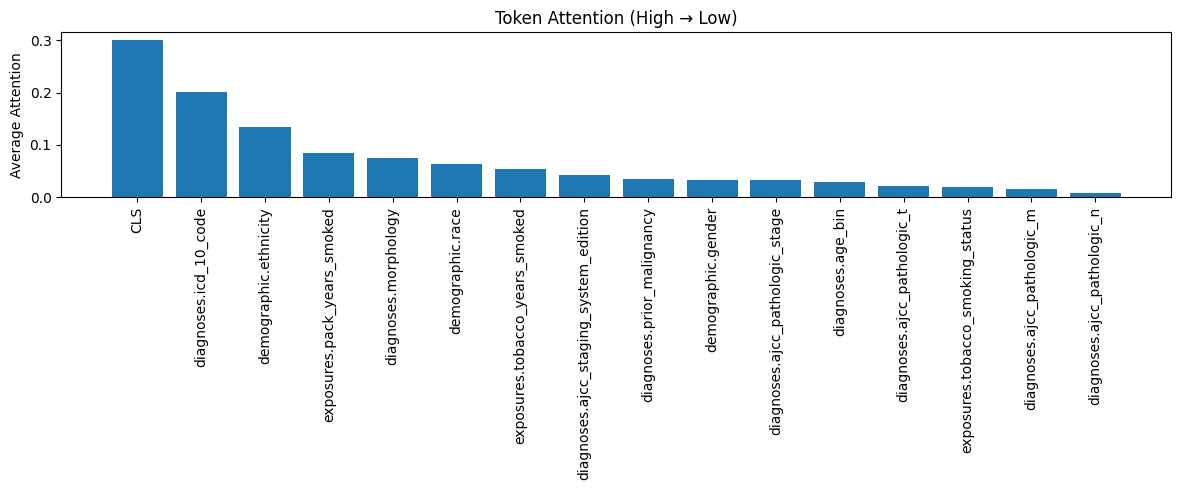

In [21]:
all_attn = []
all_masks = []

for fold, values in all_patient_results.items():
    results = values["results"]

    for pid in results.keys():
        attn, mask = get_cls_attn(results, pid)  # mask ignored
        all_attn.append(to_tensor(attn))
        all_masks.append(to_tensor(mask))
        tkn_names = results[pid]['token_names']

attn = torch.stack(all_attn, dim=0)   # (N, T)
mask = torch.stack(all_masks, dim=0)  # (N, T)

numerator = (attn * mask).sum(dim=0)
denominator = mask.sum(dim=0).clamp(min=1)

avg_attn = numerator / denominator

attn = avg_attn.detach().cpu()
idx = torch.argsort(attn, descending=True)
attn_sorted = attn[idx].numpy()
names_sorted = np.array(tkn_names)[idx.numpy()]

plt.figure(figsize=(12,5))
plt.bar(range(len(attn_sorted)), attn_sorted)
plt.xticks(range(len(attn_sorted)), names_sorted, rotation=90)
plt.ylabel("Average Attention")
plt.title("Token Attention (High → Low)")
plt.tight_layout()
plt.show()